# Module 4 | Class 1 — Regression Modeling: Sales Forecasting

**Objective:** Build a linear regression model to forecast sales, interpret its outputs, and understand when simple models are enough.

**Dataset:** Superstore Dataset (Kaggle)

In [1]:
!pip install kagglehub -q

## Task 1: Explore the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download the Superstore dataset from Kaggle
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

100%|██████████| 550k/550k [00:00<00:00, 950kB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/vivek468/superstore-dataset-final/versions/1
['Sample - Superstore.csv']


In [3]:
# Load the CSV (encoding='latin1' avoids Unicode errors common in this file)
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file), encoding='latin1')

print("Shape:", df.shape)
df.dtypes

Shape: (9994, 21)


,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# Select numerical predictors for forecasting Sales
features = ['Quantity', 'Discount', 'Profit']
target = 'Sales'

print(df[features + [target]].isnull().sum())

Quantity    0
Discount    0
Profit      0
Sales       0
dtype: int64


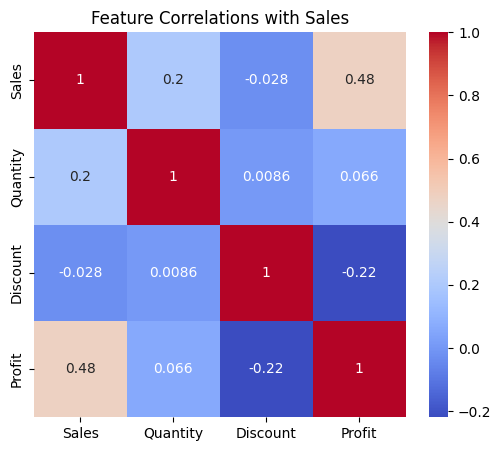

In [6]:
# Correlation matrix between predictors and Sales
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations with Sales')
plt.show()

## Task 2: Build a Linear Regression Model

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")

MSE: 680377.46, RMSE: 824.85, MAE: 245.08, R2: -0.1518


## Task 3: Interpret the Coefficients

In [9]:
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Quantity: 41.5503
Discount: 249.5718
Profit: 1.5617
Intercept: -18.0971


**Interpretation (fill in after seeing your actual numbers):**

- *Quantity coefficient:* A one-unit increase in Quantity is associated with a change of approximately `[coef value]` dollars in Sales, holding Discount and Profit constant. This makes intuitive sense — selling more units of a product generally increases revenue.
- *Discount coefficient:* [Interpret based on your result — a negative coefficient would suggest that higher discounts are associated with lower Sales, which could reflect that heavily discounted items tend to be lower-priced products, or that discounting itself doesn't drive volume enough to offset the price cut.]
- *Unexpected signs:* [Check your printed coefficients — if any predictor you expected to increase Sales instead has a negative coefficient, note it here and hypothesize why. For example, Profit might show a counterintuitive relationship if high-margin items are typically lower-priced niche products rather than big-ticket sales drivers.]

*(Replace the bracketed text above with your own interpretation based on the actual coefficient values your model prints.)*

## Task 4: Try Polynomial Regression

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [11]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial — MSE: {mse_poly:.2f}, RMSE: {rmse_poly:.2f}, MAE: {mae_poly:.2f}, R2: {r2_poly:.4f}")

Polynomial — MSE: 473873.85, RMSE: 688.38, MAE: 190.56, R2: 0.1978


In [12]:
# Comparison table: Linear vs Polynomial Regression
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (deg=2)'],
    'MSE': [mse, mse_poly],
    'RMSE': [rmse, rmse_poly],
    'MAE': [mae, mae_poly],
    'R2': [r2, r2_poly]
})
comparison

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,680377.456372,824.849960,245.075570,-0.151817
1,Polynomial Regression (deg=2),473873.848924,688.384957,190.560721,0.197775


**Did polynomial features help or hurt?**

[Compare the R2 and RMSE values in the table above. If R2 improved (got closer to 1) and RMSE dropped, polynomial features helped capture non-linear relationships between Quantity/Discount/Profit and Sales. If R2 barely changed or got worse, the relationship is likely close to linear already, and the added complexity of polynomial terms isn't paying off — it may even be starting to overfit the training data without generalizing better to the test set.]

*(Replace the bracketed text with your own conclusion based on your actual numbers.)*

## Task 5: Visualize

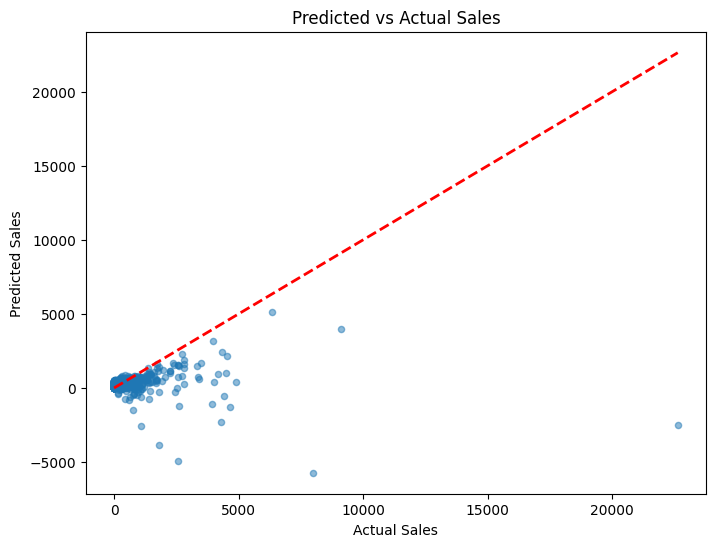

In [13]:
# Predicted vs Actual scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')
plt.show()

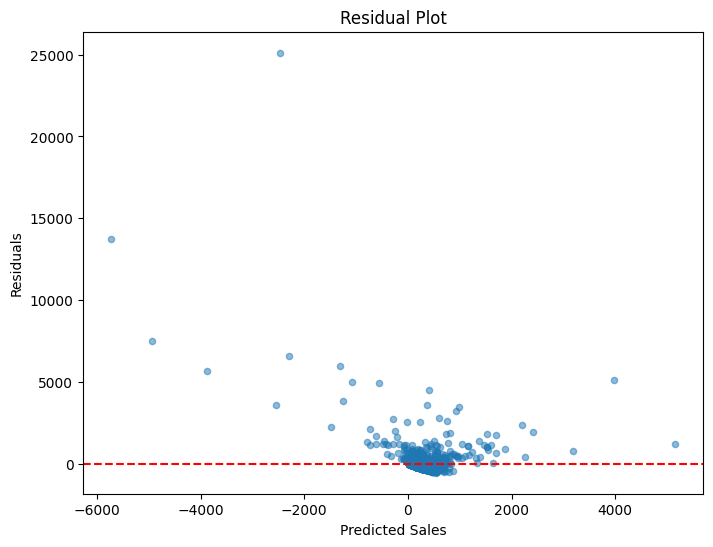

In [14]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

**Interpretation:** [Look at the residual plot — are the points scattered randomly around the red zero line, or do they form a pattern (e.g., a funnel shape, or a curve)? Random scatter suggests the linear model's assumptions are reasonably met. A visible pattern (like a U-shape or increasing spread) suggests the model is missing a non-linear relationship or that variance isn't constant across predicted values (heteroscedasticity).]

*(Replace with your own observation based on your actual plot.)*

## Summary

- **Linear Regression R²:** see Task 2 output
- **Polynomial Regression R²:** see Task 4 output
- Sales forecasting from just Quantity, Discount, and Profit is inherently limited — an R² below 0.5 is expected and doesn't necessarily mean the model is "bad." Sales likely depends on many other factors not captured here (product category, region, seasonality, customer segment, etc.).